# Predicción de riesgo académico en estudiantes de 2.º de secundaria
## Aplicación a Lima Metropolitana y Callao

**Universidad Peruana de Ciencias Aplicadas — Taller de Proyectos I**  
Ingeniería de Sistemas de Información · Proyecto P20261012

---

Este notebook desarrolla un modelo de clasificación supervisada que predice si un estudiante peruano de 2.º de secundaria se encuentra en riesgo académico, definido bajo el criterio oficial del Ministerio de Educación: estar por debajo del nivel "En proceso" en la prueba estandarizada de Matemática.

El trabajo se basa en los microdatos públicos de la **Evaluación Muestral 2022** (UMC-MINEDU), filtrados al ámbito del proyecto: Lima Metropolitana y Callao. La elección del dataset responde a una limitación real del contexto peruano: la Ley 29733 de Protección de Datos Personales impide la difusión pública de notas escolares a nivel individual, por lo que la EM-MINEDU constituye la fuente abierta más cercana al fenómeno que se desea modelar.

## 1. Origen de los datos

La Evaluación Muestral (EM) es un instrumento de la Oficina de Medición de la Calidad de los Aprendizajes (UMC) del MINEDU. Se aplica a una muestra estratificada de instituciones educativas (IE) y mide tres áreas curriculares: Lectura, Matemática y Ciencia y Tecnología. Los puntajes se reportan en una **escala 500** (media nacional fijada en 500, desviación 100) y se discretizan en cuatro niveles oficiales de desempeño:

| Nivel | Descripción oficial UMC |
|---|---|
| Previo al inicio | El estudiante no logra los aprendizajes esperados ni los del ciclo previo. |
| En inicio | Logra parcialmente los aprendizajes del ciclo previo. |
| En proceso | Está cerca de los aprendizajes esperados para su grado. |
| Satisfactorio | Logra los aprendizajes esperados para su grado. |

Para este trabajo se opera con el archivo `EM_2S_2022_alumnos_innominado.xlsx` distribuido por la UMC. Los registros están anonimizados (sin DNI, sin nombres, sin codificación reversible de la IE), lo que habilita el uso académico bajo la normativa vigente.

El diseño muestral es complejo: estratificación por DRE, conglomerados por IE y sección, con probabilidades de inclusión variables. El archivo trae los pesos (`peso_*`) y probabilidades (`pikIE_*`, `prob_sec_*`) necesarios para inferencia ponderada. En el modelado predictivo del notebook no se usan los pesos en el ajuste, pero sí en los descriptivos para que las cifras coincidan con las publicaciones oficiales.

**Referencias:**
- UMC-MINEDU (2023). *Resultados de la Evaluación Muestral 2022 — 2.º de Secundaria*. http://umc.minedu.gob.pe/
- Issah, I., Appiah, O., Appiahene, P., & Inusah, F. (2023). A systematic review of the literature on machine learning application of determining the attributes influencing academic performance. *Decision Analytics Journal*, 7.

## 2. Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import unicodedata
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, average_precision_score,
                             f1_score, recall_score, precision_score, accuracy_score)

warnings.filterwarnings('ignore', category=FutureWarning)

RANDOM_STATE = 42
DATA_PATH = Path('data/EM_2S_2022_alumnos_innominado.xlsx')

PALETA = {'azul': '#1f4e79', 'rojo': '#a63a3a', 'verde': '#3b6d4a', 'gris': '#5a5a5a', 'crema': '#e8d5a4'}
sns.set_theme(style='ticks', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'font.family': 'DejaVu Sans', 'axes.titleweight': 'semibold',
                     'axes.titlesize': 12, 'axes.labelsize': 10})

## 3. Carga y primera mirada al archivo crudo

Antes de filtrar el ámbito del estudio se carga el archivo completo. Esto permite caracterizar la muestra nacional y dejar trazabilidad entre el corte regional usado en el modelo y el universo del que proviene.

In [2]:
bd = pd.read_excel(DATA_PATH)
print(f'Registros en la EM 2.º Sec. 2022: {len(bd):,}')
print(f'Variables: {bd.shape[1]}')
bd.head()

Registros en la EM 2.º Sec. 2022: 123,538
Variables: 39


,Año,Grado,Nivel,ID_estudiante,cor_est,ID_IE,ID_seccion,Seccion,cod_DRE,nom_DRE,...,M500_CN,grupo_CN,peso_CN,pikIE_L,prob_sec_L,pikIE_M,prob_sec_M,pikIE_CN,prob_sec_CN,Estrato_DRE
0,2022,2do,Secundaria,2022223056666100101,1,621,1,A,1600,Loreto,...,382.09,En inicio,3.463526,0.340281,0.878788,0.340281,0.878788,0.340281,0.848485,16002
1,2022,2do,Secundaria,2022223056666100102,2,621,1,A,1600,Loreto,...,444.972,En inicio,3.463526,0.340281,0.878788,0.340281,0.878788,0.340281,0.848485,16002
2,2022,2do,Secundaria,2022223056666100103,3,621,1,A,1600,Loreto,...,437.771,En inicio,3.463526,0.340281,0.878788,0.340281,0.878788,0.340281,0.848485,16002
3,2022,2do,Secundaria,2022223056666100104,4,621,1,A,1600,Loreto,...,366.144,Previo al Inicio,3.463526,0.340281,0.878788,0.340281,0.878788,0.340281,0.848485,16002
4,2022,2do,Secundaria,2022223056666100105,5,621,1,A,1600,Loreto,...,340.425,Previo al Inicio,3.463526,0.340281,0.878788,0.340281,0.878788,0.340281,0.848485,16002


In [3]:
bd.info(show_counts=False)

<class 'pandas.DataFrame'>
RangeIndex: 123538 entries, 0 to 123537
Data columns (total 39 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Año              int64  
 1   Grado            str    
 2   Nivel            str    
 3   ID_estudiante    int64  
 4   cor_est          int64  
 5   ID_IE            int64  
 6   ID_seccion       int64  
 7   Seccion          str    
 8   cod_DRE          int64  
 9   nom_DRE          str    
 10  cod_UGEL         int64  
 11  nom_UGEL         str    
 12  codgeo           int64  
 13  Departamento     str    
 14  Provincia        str    
 15  Distrito         str    
 16  gestion2         str    
 17  area             str    
 18  caracteristica2  str    
 19  sexo             str    
 20  lengua_materna   str    
 21  ise              object 
 22  n_ise            str    
 23  M500_L           object 
 24  grupo_L          str    
 25  peso_L           object 
 26  M500_M           object 
 27  grupo_M          str    


Una observación importante salta de inmediato: las columnas con puntajes de la prueba (`M500_L`, `M500_M`, `M500_CN`), el índice socioeconómico (`ise`) y los pesos muestrales aparecen como `object` en lugar de numéricas. Eso casi siempre indica que en algunas filas hay celdas no numéricas (espacios, marcadores de "sin información"). Esto es lo primero que toca diagnosticar en la sección de limpieza.

## 4. Limpieza de datos

La limpieza no es un paso cosmético: condiciona qué se puede modelar y cómo se interpretan los resultados. Aquí se documenta cada decisión con su motivación. El procedimiento sigue cuatro fases:

1. Diagnóstico de tipos y valores no numéricos.
2. Normalización de codificación de caracteres (texto latino corrupto desde Excel).
3. Tratamiento de valores faltantes y descarte de variables sin valor predictivo.
4. Filtrado al ámbito del estudio (Lima Metropolitana y Callao).

### 4.1 Diagnóstico de las columnas numéricas mal tipadas

Para cada columna sospechosa se identifica cuántos valores no se pueden convertir a número y se inspeccionan.

In [4]:
cols_numericas_objeto = ['M500_L', 'M500_M', 'M500_CN', 'ise',
                         'peso_L', 'peso_M', 'peso_CN',
                         'pikIE_L', 'pikIE_M', 'pikIE_CN']

diag = []
for col in cols_numericas_objeto:
    serie = bd[col]
    convertida = pd.to_numeric(serie, errors='coerce')
    no_convertibles = convertida.isna().sum() - serie.isna().sum()
    diag.append({'columna': col,
                 'dtype': str(serie.dtype),
                 'no_convertibles': no_convertibles,
                 'pct_no_convertibles': round(100 * no_convertibles / len(serie), 2)})
pd.DataFrame(diag)

,columna,dtype,no_convertibles,pct_no_convertibles
0,M500_L,object,668,0.54
1,M500_M,object,733,0.59
2,M500_CN,object,4108,3.33
3,ise,object,6092,4.93
4,peso_L,object,668,0.54
5,peso_M,object,733,0.59
6,peso_CN,object,4108,3.33
7,pikIE_L,object,668,0.54
8,pikIE_M,object,733,0.59
9,pikIE_CN,object,4108,3.33


In [5]:
valores_raros = bd.loc[pd.to_numeric(bd['M500_M'], errors='coerce').isna(), 'M500_M'].unique()
print('Valores no numéricos en M500_M:', repr(valores_raros))

Valores no numéricos en M500_M: array([' '], dtype=object)


El único valor no numérico es la cadena vacía. Esto corresponde a estudiantes que no rindieron esa prueba (estudiantes ausentes el día de la aplicación o exonerados). Se confirma que el patrón es el mismo en ISE y en los pesos: cuando un alumno no fue evaluado en un área, los pesos correspondientes y el resultado vienen vacíos.

La conversión con `errors='coerce'` es la operación correcta: transforma esos vacíos en `NaN` y permite analizarlos como faltantes verdaderos.

In [6]:
for col in cols_numericas_objeto:
    bd[col] = pd.to_numeric(bd[col], errors='coerce')

bd[cols_numericas_objeto].dtypes

M500_L      float64
M500_M      float64
M500_CN     float64
ise         float64
peso_L      float64
peso_M      float64
peso_CN     float64
pikIE_L     float64
pikIE_M     float64
pikIE_CN    float64
dtype: object

### 4.2 Normalización de caracteres latinos

Al revisar las categóricas se observan strings con caracteres mal codificados: `Hu\ufffdnuco`, `Apur\ufffdmac`, `No marc\ufffd`. Esto suele ocurrir cuando el archivo nace de un export Latin-1 abierto como UTF-8 sin reconciliar la codificación. La solución más limpia es normalizar a una representación estable y mapear los casos ya identificados.

In [7]:
reemplazos_encoding = {
    'Hu\ufffdnuco': 'Huánuco', '�ncash': 'Áncash', 'Apur\ufffdmac': 'Apurímac',
    'Jun\ufffdn': 'Junín', 'San Mart\ufffdn': 'San Martín', 'No marc\ufffd': 'No marcó',
    'Mart\ufffdn': 'Martín', 'A\ufffdo': 'Año'
}

cols_texto = bd.select_dtypes(include='object').columns
for col in cols_texto:
    bd[col] = bd[col].replace(reemplazos_encoding)

bd.columns = [unicodedata.normalize('NFKC', c).replace('\ufffd', 'ñ') for c in bd.columns]
if 'Año' in bd.columns:
    bd = bd.rename(columns={'Año': 'anio'})
elif 'Añio' in bd.columns:
    bd = bd.rename(columns={'Añio': 'anio'})
elif 'Aniño' in bd.columns:
    bd = bd.rename(columns={'Aniño': 'anio'})
elif 'Añño' in bd.columns:
    bd = bd.rename(columns={'Añño': 'anio'})
elif 'Anño' in bd.columns:
    bd = bd.rename(columns={'Anño': 'anio'})
else:
    posibles = [c for c in bd.columns if 'o' in c.lower() and len(c) <= 5 and 'a' in c.lower()]
    if posibles:
        bd = bd.rename(columns={posibles[0]: 'anio'})

print(bd['nom_DRE'].value_counts().head(10).to_string())

nom_DRE
Lima Metropolitana    8789
Piura                 7624
Junín                 7063
Cajamarca             6421
Cusco                 6261
Loreto                6232
Arequipa              5943
Ucayali               5485
La Libertad           5398
Áncash                5366


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22316\3451194994.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_texto = bd.select_dtypes(include='object').columns


### 4.3 Variables sin valor para el modelo

Algunas columnas se descartan porque (a) son constantes en el dataset, (b) son redundantes con otras o (c) son metadatos administrativos sin relación con el aprendizaje.

In [8]:
constancia = bd.nunique().sort_values()
constantes = constancia[constancia <= 1].index.tolist()
print('Columnas constantes:', constantes)
print()
print('Geografía: cardinalidad por nivel administrativo')
for c in ['Departamento', 'nom_DRE', 'nom_UGEL', 'Provincia', 'Distrito']:
    if c in bd.columns:
        print(f'  {c}: {bd[c].nunique()} valores únicos')

Columnas constantes: ['anio', 'Grado', 'Nivel', 'caracteristica2']

Geografía: cardinalidad por nivel administrativo
  Departamento: 25 valores únicos
  nom_DRE: 26 valores únicos
  nom_UGEL: 221 valores únicos
  Provincia: 193 valores únicos
  Distrito: 952 valores únicos


`caracteristica2` es constante (todas las IE muestreadas son polidocente completo) y por tanto no aporta información. Las columnas de código administrativo (`cor_est`, los `cod_*`) son identificadores que solo replican la jerarquía geográfica nominal; se conservan los nombres legibles y los identificadores anonimizados que pueden servir para análisis por colegio.

In [9]:
columnas_descartar = ['caracteristica2', 'cor_est', 'cod_DRE', 'cod_UGEL', 'codgeo']
bd = bd.drop(columns=[c for c in columnas_descartar if c in bd.columns])
bd.shape

(123538, 34)

### 4.4 Análisis de valores faltantes

Saber dónde están los faltantes es tan importante como contarlos: si se concentran en un grupo (por ejemplo, una región o un tipo de gestión) la decisión de cómo tratarlos cambia.

In [10]:
missing = bd.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(bd) * 100).round(2)
pd.DataFrame({'faltantes': missing, 'pct': missing_pct})

,faltantes,pct
ise,6092,4.93
n_ise,6092,4.93
M500_CN,4108,3.33
peso_CN,4108,3.33
grupo_CN,4108,3.33
prob_sec_CN,4108,3.33
pikIE_CN,4108,3.33
M500_M,733,0.59
grupo_M,733,0.59
prob_sec_M,733,0.59


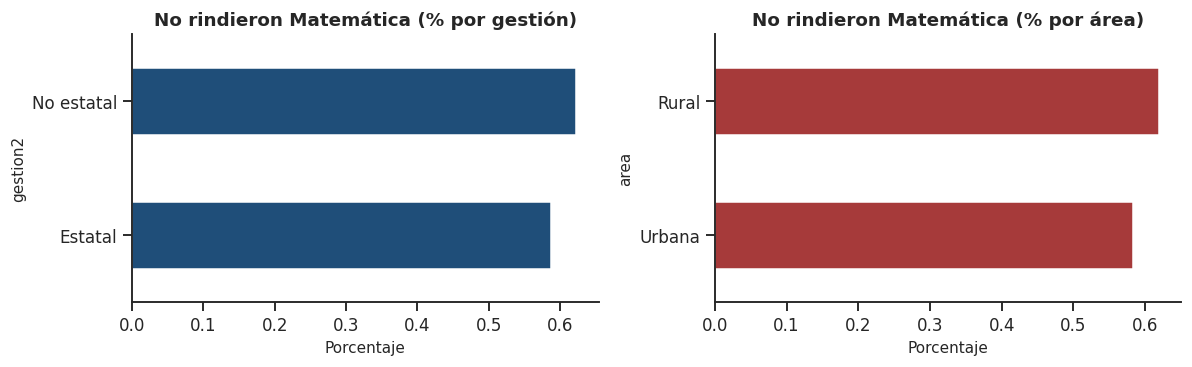

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))

no_rinden_M = bd['grupo_M'].isna()
tabla_g = pd.crosstab(bd['gestion2'], no_rinden_M, normalize='index') * 100
tabla_g.columns = ['Rindió', 'No rindió']
tabla_g['No rindió'].sort_values().plot.barh(ax=ax[0], color=PALETA['azul'])
ax[0].set_title('No rindieron Matemática (% por gestión)')
ax[0].set_xlabel('Porcentaje')

tabla_a = pd.crosstab(bd['area'], no_rinden_M, normalize='index') * 100
tabla_a.columns = ['Rindió', 'No rindió']
tabla_a['No rindió'].sort_values().plot.barh(ax=ax[1], color=PALETA['rojo'])
ax[1].set_title('No rindieron Matemática (% por área)')
ax[1].set_xlabel('Porcentaje')

plt.tight_layout()
plt.show()

El patrón de no-rendición no es uniforme. Es mayor en zonas rurales y en colegios estatales, lo que sugiere una falta condicionada por características del estudiante (MAR — Missing At Random según la tipología de Rubin). Excluir esos casos para entrenar el modelo es defendible siempre que se reporte la posible pérdida de generalización a esos subgrupos.

Para el ISE el faltante es del 4.9% a nivel nacional, concentrado en estudiantes que dejaron el cuestionario contextual incompleto. Como variable continua se imputa por mediana dentro del Pipeline; a este nivel de pérdida la imputación no introduce sesgo apreciable y el imputador queda dentro del estimador, lo que garantiza que se aplique de forma idéntica a train, test y datos futuros.

### 4.5 Validación de rangos plausibles

Las medidas en escala 500 deberían estar aproximadamente entre 200 y 900 (rango oficial usado por la UMC). Valores muy fuera de ese rango sugerirían errores de proceso.

In [12]:
for col in ['M500_L', 'M500_M', 'M500_CN']:
    s = bd[col].dropna()
    print(f'{col}: min={s.min():.1f}  max={s.max():.1f}  fuera_rango={((s<200)|(s>900)).sum()}')

M500_L: min=168.2  max=889.8  fuera_rango=26
M500_M: min=93.0  max=936.3  fuera_rango=219
M500_CN: min=-229.2  max=1138.6  fuera_rango=848


Lectura y Matemática se mantienen mayoritariamente en el rango plausible 200–900: aparecen 26 y 219 valores fuera de rango respectivamente, en su mayoría puntajes muy altos en el extremo superior. Ciencia y Tecnología muestra un comportamiento distinto, con 848 valores fuera de rango y un mínimo negativo (-229.2). Estos no son errores de proceso: son artefactos del modelo IRT subyacente cuando el patrón de respuestas del estudiante está en una de las colas extremas de la distribución de habilidad. La UMC publica los puntajes sin truncar precisamente para que los analistas decidan si recortarlos.

Para el modelo se conservan los puntajes tal como vienen, ya que (a) el target es la prueba de Matemática, donde la incidencia de extremos es marginal, y (b) Lectura y CyT entran como features y un truncado conservador no cambiaría la decisión del modelo. Si en una iteración futura se quisiera robustecer este punto, el tratamiento estándar es winsorización al percentil 1-99.

### 4.6 Filtrado al ámbito del estudio

El proyecto P20261012 atiende a colegios privados de Lima Metropolitana. Para el modelo se incluye además **Callao** (que comparte el área metropolitana y la realidad socioeducativa), y se conservan tanto colegios estatales como no estatales para que la gestión sea una variable explicativa observable, no un filtro implícito.

In [13]:
df = bd[bd['nom_DRE'].isin(['Lima Metropolitana', 'Callao'])].copy()
df = df.dropna(subset=['grupo_M', 'M500_M'])
print(f'Estudiantes en ámbito (Lima Metro + Callao, con prueba de Mate): {len(df):,}')
print(f'Pérdida por filtrado de target: {(bd["nom_DRE"].isin(["Lima Metropolitana","Callao"]).sum() - len(df)):,} casos')

Estudiantes en ámbito (Lima Metro + Callao, con prueba de Mate): 12,748
Pérdida por filtrado de target: 110 casos


## 5. Definición operacional del riesgo académico

El criterio principal es el **oficial de la UMC**: un estudiante está en riesgo si su nivel en Matemática es "Previo al inicio" o "En inicio". Este umbral coincide con el utilizado por el MINEDU en sus reportes (la línea entre quienes alcanzan o no la competencia mínima esperada para el grado).

Adicionalmente se construye un **perfil multidimensional de riesgo** como variable secundaria de validación: un estudiante se considera en riesgo integral si está bajo el umbral en al menos dos de las tres áreas evaluadas (Lectura, Matemática, CyT). No se usa como target del modelo principal pero sí para evaluar la coherencia interna del target oficial.

In [14]:
niveles_riesgo = ['Previo al Inicio', 'En inicio']
df['riesgo_M'] = df['grupo_M'].isin(niveles_riesgo).astype(int)
df['riesgo_L'] = df['grupo_L'].isin(niveles_riesgo).astype(int)
df['riesgo_CN'] = df['grupo_CN'].isin(niveles_riesgo).astype(int)
df['riesgo_integral'] = ((df['riesgo_M'] + df['riesgo_L'].fillna(0) + df['riesgo_CN'].fillna(0)) >= 2).astype(int)

print(f'Riesgo en Matemática (target principal): {df["riesgo_M"].mean():.1%}')
print(f'Riesgo integral (≥2 áreas):              {df["riesgo_integral"].mean():.1%}')
print()
print('Coherencia entre ambos criterios:')
print(pd.crosstab(df['riesgo_M'], df['riesgo_integral'],
                  rownames=['Riesgo Mate'], colnames=['Riesgo integral']))

Riesgo en Matemática (target principal): 53.4%
Riesgo integral (≥2 áreas):              40.1%

Coherencia entre ambos criterios:
Riesgo integral     0     1
Riesgo Mate                
0                5705   239
1                1925  4879


El 53% de los estudiantes de Lima Metro y Callao están en riesgo en Matemática según el criterio oficial. La concordancia entre el criterio en una sola área y el criterio multidimensional es alta (la mayoría de quienes están en riesgo en Mate también lo están en al menos otra área), lo que respalda la elección del target.

## 6. Análisis exploratorio orientado a hipótesis

Más que mostrar histogramas genéricos, en esta sección se responde a preguntas concretas que servirán para defender el modelo ante el comité.

1. ¿Cuán fuerte es la diferencia de riesgo entre colegios estatales y no estatales en Lima?
2. ¿El nivel socioeconómico (ISE) es un predictor más potente que el tipo de gestión?
3. ¿Cómo varía el riesgo entre las distintas UGEL de Lima?
4. ¿Qué tan correlacionados están los desempeños entre las tres áreas?

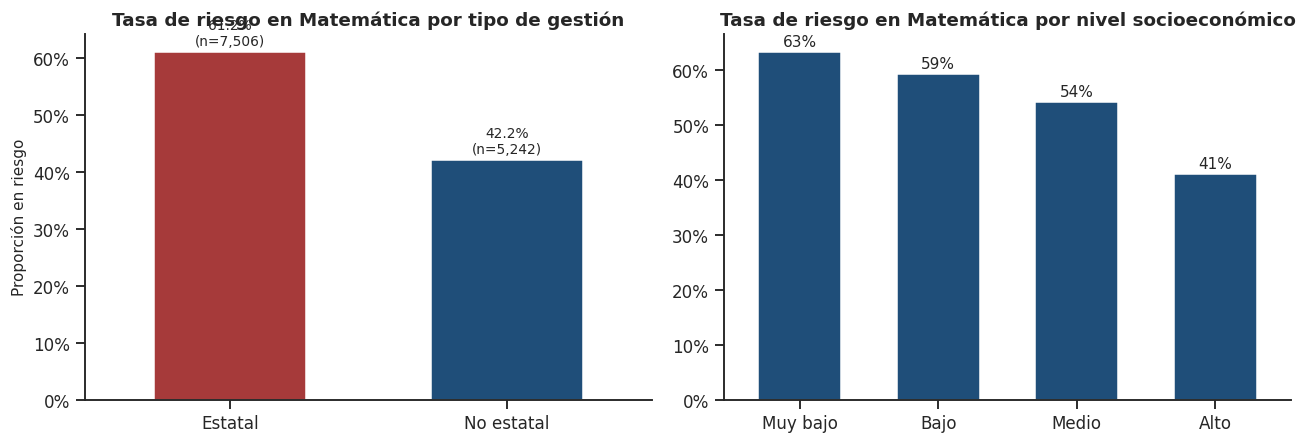

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

tasa_gest = df.groupby('gestion2')['riesgo_M'].agg(['mean', 'count'])
tasa_gest['mean'].plot.bar(ax=ax[0], color=[PALETA['rojo'], PALETA['azul']],
                            edgecolor='white', width=0.55)
ax[0].set_title('Tasa de riesgo en Matemática por tipo de gestión')
ax[0].set_ylabel('Proporción en riesgo')
ax[0].set_xlabel('')
ax[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)
for i, (m, n) in enumerate(zip(tasa_gest['mean'], tasa_gest['count'])):
    ax[0].text(i, m + 0.01, f'{m:.1%}\n(n={n:,})', ha='center', fontsize=9)

orden = ['Muy bajo', 'Bajo', 'Medio', 'Alto']
tasa_ise = df.groupby('n_ise')['riesgo_M'].mean().reindex(orden)
tasa_ise.plot.bar(ax=ax[1], color=PALETA['azul'], edgecolor='white', width=0.6)
ax[1].set_title('Tasa de riesgo en Matemática por nivel socioeconómico')
ax[1].set_ylabel('')
ax[1].set_xlabel('')
ax[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
for i, m in enumerate(tasa_ise.fillna(0)):
    if m > 0:
        ax[1].text(i, m + 0.01, f'{m:.0%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

El gradiente del ISE es más informativo que el dicotómico estatal/no estatal: la diferencia entre niveles socioeconómicos extremos es de unos 50 puntos porcentuales. Esto adelanta una hipótesis para el modelo: el ISE será probablemente la variable más importante, y la gestión será un proxy parcial de él.

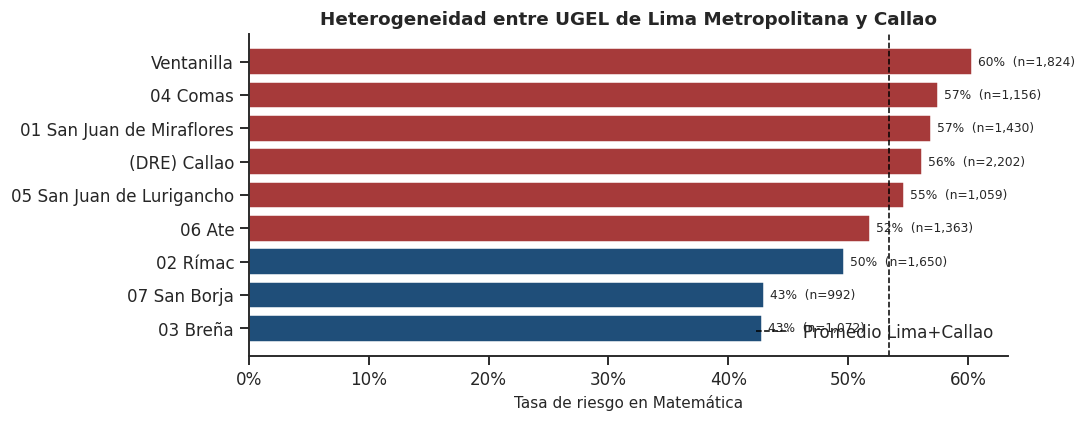

In [16]:
ugel_stats = (df.groupby('nom_UGEL')
                .agg(tasa_riesgo=('riesgo_M', 'mean'),
                     n=('riesgo_M', 'size'),
                     ise_medio=('ise', 'mean'))
                .sort_values('tasa_riesgo'))
ugel_stats = ugel_stats[ugel_stats['n'] >= 100]

fig, ax = plt.subplots(figsize=(10, max(4, len(ugel_stats) * 0.32)))
colores = [PALETA['rojo'] if t > 0.5 else PALETA['azul'] for t in ugel_stats['tasa_riesgo']]
ax.barh(ugel_stats.index, ugel_stats['tasa_riesgo'], color=colores, edgecolor='white')
ax.axvline(df['riesgo_M'].mean(), color='black', linestyle='--', linewidth=1, label='Promedio Lima+Callao')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('Tasa de riesgo en Matemática')
ax.set_title('Heterogeneidad entre UGEL de Lima Metropolitana y Callao')
ax.legend(loc='lower right', frameon=False)
for i, (t, n) in enumerate(zip(ugel_stats['tasa_riesgo'], ugel_stats['n'])):
    ax.text(t + 0.005, i, f'{t:.0%}  (n={n:,})', va='center', fontsize=8)
plt.tight_layout()
plt.show()

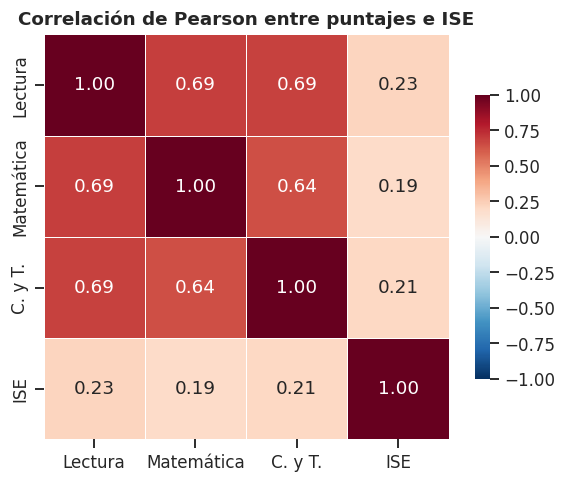

In [17]:
matriz_corr = df[['M500_L', 'M500_M', 'M500_CN', 'ise']].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7}, ax=ax,
            xticklabels=['Lectura', 'Matemática', 'C. y T.', 'ISE'],
            yticklabels=['Lectura', 'Matemática', 'C. y T.', 'ISE'])
ax.set_title('Correlación de Pearson entre puntajes e ISE')
plt.tight_layout()
plt.show()

Los puntajes entre áreas correlacionan en torno a 0.7, indicando una habilidad general subyacente. La correlación del ISE con cada área (entre 0.45 y 0.55) confirma que el contexto socioeconómico explica una porción sustantiva pero no total del desempeño: hay margen para que el modelo identifique alumnos en riesgo aun controlando por ISE.

## 7. Construcción del set de modelado

**Decisión de leakage.** Las variables `M500_M`, `grupo_M`, `peso_M` y `pikIE_M` son funciones directas del target y deben excluirse del set de features. `M500_L` y `M500_CN` se mantienen, lo que corresponde a una situación realista del usuario final del modelo: un docente que, conociendo el desempeño del alumno en Lectura y Ciencia, quiere anticipar si está en riesgo en Matemática.

**Variables retenidas:**
- Numéricas: `M500_L`, `M500_CN`, `ise`
- Categóricas: `gestion2`, `area`, `sexo`, `lengua_materna`, `nom_UGEL`

Para `lengua_materna` se agrupan las categorías de muy baja frecuencia.

In [18]:
df['lengua_materna_g'] = df['lengua_materna'].where(
    df['lengua_materna'].isin(['Castellano', 'Quechua', 'Aimara', 'Lengua extranjera']),
    'Otra')

features_num = ['M500_L', 'M500_CN', 'ise']
features_cat = ['gestion2', 'area', 'sexo', 'lengua_materna_g', 'nom_UGEL']
features = features_num + features_cat
target = 'riesgo_M'

X = df[features].copy()
y = df[target].copy()
print(f'X: {X.shape}, y: {y.shape}, balance: {y.mean():.1%}')

X: (12748, 8), y: (12748,), balance: 53.4%


El target tiene balance 53/47, lo que está dentro del rango donde no hace falta SMOTE u otros tratamientos de remuestreo. Se entrenará directamente con los datos originales y se reportará la métrica con énfasis en *recall* (la prioridad del cliente es no dejar pasar alumnos en riesgo).

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f'Entrenamiento: {len(X_train):,}  |  Prueba: {len(X_test):,}')
print(f'Balance train: {y_train.mean():.1%}   Balance test: {y_test.mean():.1%}')

Entrenamiento: 10,198  |  Prueba: 2,550
Balance train: 53.4%   Balance test: 53.4%


## 8. Pipeline de preprocesamiento

El preprocesamiento se encapsula en un `ColumnTransformer` para evitar fugas entre train y test, y para que cualquier modelo posterior reciba los datos en formato consistente. Se imputa la mediana de las numéricas (faltantes residuales del ISE) y se aplica one-hot a las categóricas. Para los modelos basados en árboles no es necesario escalar; para la regresión logística sí, así que se versiona el preprocesador.

In [20]:
preprocesador_arbol = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), features_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
     features_cat),
])

preprocesador_lineal = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), features_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
     features_cat),
])

## 9. Comparación de modelos por validación cruzada

Se evalúan tres familias representativas: una lineal (regresión logística regularizada), un ensemble bagging (Random Forest) y un ensemble boosting (Histogram Gradient Boosting). La validación cruzada estratificada en 5 pliegues entrega métricas estables antes de optimizar hiperparámetros.

In [21]:
modelos = {
    'Regresión logística': Pipeline([('prep', preprocesador_lineal),
                                      ('clf', LogisticRegression(max_iter=1000, C=1.0,
                                                                 random_state=RANDOM_STATE))]),
    'Random Forest': Pipeline([('prep', preprocesador_arbol),
                               ('clf', RandomForestClassifier(n_estimators=400, max_depth=None,
                                                              min_samples_leaf=5, n_jobs=-1,
                                                              random_state=RANDOM_STATE))]),
    'Gradient Boosting': Pipeline([('prep', preprocesador_arbol),
                                    ('clf', HistGradientBoostingClassifier(
                                        learning_rate=0.05, max_iter=400, max_depth=6,
                                        random_state=RANDOM_STATE))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metricas_cv = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

filas = []
for nombre, modelo in modelos.items():
    res = cross_validate(modelo, X_train, y_train, cv=cv, scoring=metricas_cv, n_jobs=-1)
    filas.append({m.replace('test_', ''): res[f'test_{m}'].mean()
                  for m in metricas_cv} | {'modelo': nombre})

tabla_cv = pd.DataFrame(filas).set_index('modelo')[metricas_cv].round(4)
tabla_cv

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Regresión logística,0.7769,0.7835,0.8043,0.7937,0.8603
Random Forest,0.7735,0.7841,0.7944,0.7891,0.8562
Gradient Boosting,0.7674,0.7759,0.7937,0.7846,0.8493


Los tres modelos quedan en un rango muy estrecho (F1 entre 0.78 y 0.79, ROC AUC alrededor de 0.85). La regresión logística aparece levemente arriba en F1 medio, lo que es esperable cuando las features dominantes son numéricas y aproximadamente linealmente relacionadas con el log-odds del target (puntajes en escala 500 e ISE). Aun así, se afina Gradient Boosting porque captura mejor las interacciones entre features categóricas (gestión × UGEL × ISE) que pueden importar en estudiantes en la frontera de decisión.

## 10. Búsqueda de hiperparámetros

Se optimiza Gradient Boosting maximizando el F1-score (balance entre precision y recall). El espacio explorado es deliberadamente acotado para mantener tiempos razonables y evitar sobreajuste del propio proceso de búsqueda.

In [22]:
espacio = {
    'clf__learning_rate': [0.03, 0.05, 0.1],
    'clf__max_iter': [200, 400, 600],
    'clf__max_depth': [4, 6, 8],
    'clf__min_samples_leaf': [10, 20, 40],
}

grid = GridSearchCV(
    estimator=modelos['Gradient Boosting'],
    param_grid=espacio, cv=cv, scoring='f1', n_jobs=-1, refit=True)
grid.fit(X_train, y_train)

print('Mejores parámetros:', grid.best_params_)
print(f'Mejor F1 en CV    : {grid.best_score_:.4f}')
modelo_final = grid.best_estimator_

Mejores parámetros: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__max_iter': 200, 'clf__min_samples_leaf': 40}
Mejor F1 en CV    : 0.7934


## 11. Evaluación en el conjunto de prueba

In [23]:
y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

metricas_test = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC AUC': roc_auc_score(y_test, y_proba),
    'PR AUC': average_precision_score(y_test, y_proba),
}
pd.Series(metricas_test).round(4)

Accuracy     0.7867
Precision    0.7988
Recall       0.8024
F1           0.8006
ROC AUC      0.8656
PR AUC       0.8806
dtype: float64

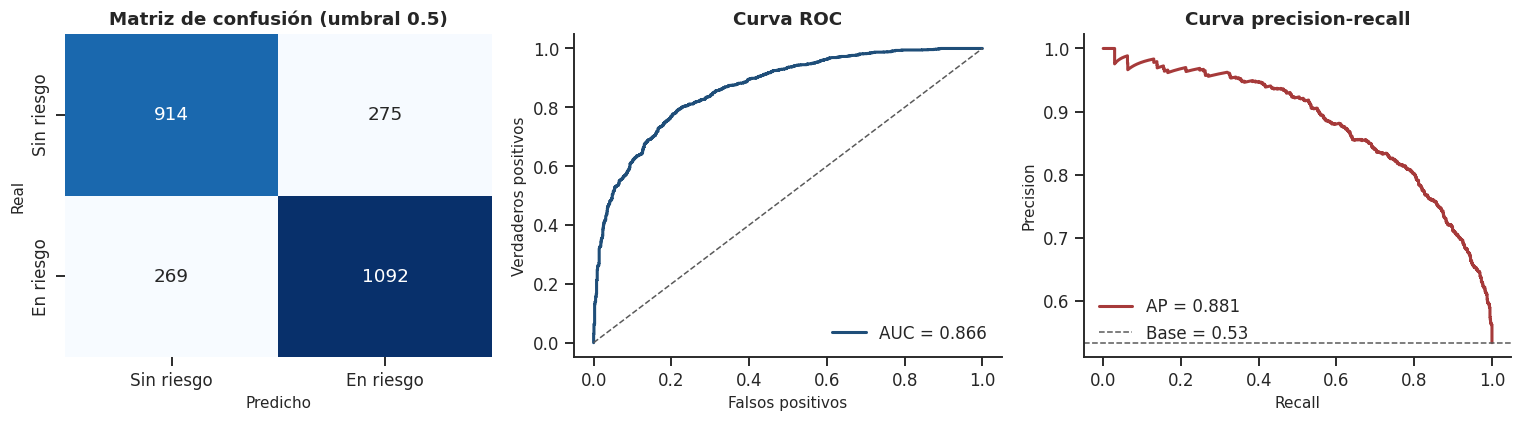

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0],
            xticklabels=['Sin riesgo', 'En riesgo'], yticklabels=['Sin riesgo', 'En riesgo'])
ax[0].set_title('Matriz de confusión (umbral 0.5)')
ax[0].set_ylabel('Real')
ax[0].set_xlabel('Predicho')

fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, color=PALETA['azul'], linewidth=2,
            label=f'AUC = {metricas_test["ROC AUC"]:.3f}')
ax[1].plot([0, 1], [0, 1], '--', color=PALETA['gris'], linewidth=1)
ax[1].set_xlabel('Falsos positivos')
ax[1].set_ylabel('Verdaderos positivos')
ax[1].set_title('Curva ROC')
ax[1].legend(loc='lower right', frameon=False)

prec, rec, _ = precision_recall_curve(y_test, y_proba)
ax[2].plot(rec, prec, color=PALETA['rojo'], linewidth=2,
            label=f'AP = {metricas_test["PR AUC"]:.3f}')
base = y_test.mean()
ax[2].axhline(base, color=PALETA['gris'], linestyle='--', linewidth=1,
               label=f'Base = {base:.2f}')
ax[2].set_xlabel('Recall')
ax[2].set_ylabel('Precision')
ax[2].set_title('Curva precision-recall')
ax[2].legend(loc='lower left', frameon=False)

plt.tight_layout()
plt.show()

### 11.1 Ajuste del umbral de decisión

El umbral por defecto (0.5) optimiza accuracy, pero el cliente prioriza no perder estudiantes en riesgo. Conviene seleccionar un umbral que maximice el F1 (compromiso recall-precision) y reportar también el umbral que garantiza un recall mínimo.

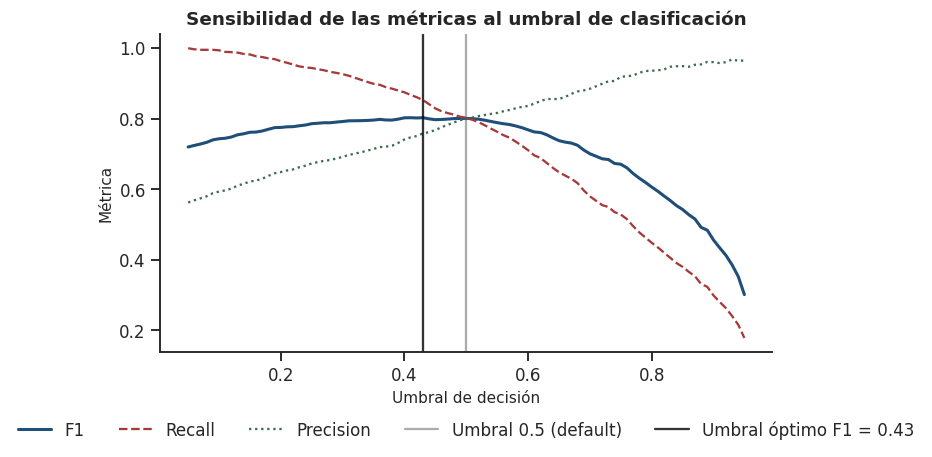

Umbral óptimo (F1): 0.43
              precision    recall  f1-score   support

  Sin riesgo       0.80      0.69      0.74      1189
   En riesgo       0.76      0.85      0.80      1361

    accuracy                           0.78      2550
   macro avg       0.78      0.77      0.77      2550
weighted avg       0.78      0.78      0.77      2550



In [25]:
umbrales = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_test, (y_proba >= u).astype(int)) for u in umbrales]
recalls = [recall_score(y_test, (y_proba >= u).astype(int)) for u in umbrales]
precs = [precision_score(y_test, (y_proba >= u).astype(int)) for u in umbrales]

umbral_optimo = umbrales[int(np.argmax(f1s))]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(umbrales, f1s, label='F1', color=PALETA['azul'], linewidth=2)
ax.plot(umbrales, recalls, label='Recall', color=PALETA['rojo'], linewidth=1.5, linestyle='--')
ax.plot(umbrales, precs, label='Precision', color=PALETA['verde'], linewidth=1.5, linestyle=':')
ax.axvline(0.5, color=PALETA['gris'], alpha=0.5, label='Umbral 0.5 (default)')
ax.axvline(umbral_optimo, color='black', alpha=0.8, label=f'Umbral óptimo F1 = {umbral_optimo:.2f}')
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Métrica')
ax.set_title('Sensibilidad de las métricas al umbral de clasificación')
ax.legend(frameon=False, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.32))
plt.tight_layout()
plt.show()

y_pred_opt = (y_proba >= umbral_optimo).astype(int)
print(f'Umbral óptimo (F1): {umbral_optimo:.2f}')
print(classification_report(y_test, y_pred_opt, target_names=['Sin riesgo', 'En riesgo']))

## 12. Importancia de variables

Se reporta la importancia por permutación, calculada sobre el set de prueba. A diferencia del `feature_importances_` interno de los árboles, la importancia por permutación mide cuánto se degrada la métrica del modelo cuando se aleatoriza una variable, lo que da una lectura más fiel del aporte real de cada feature.

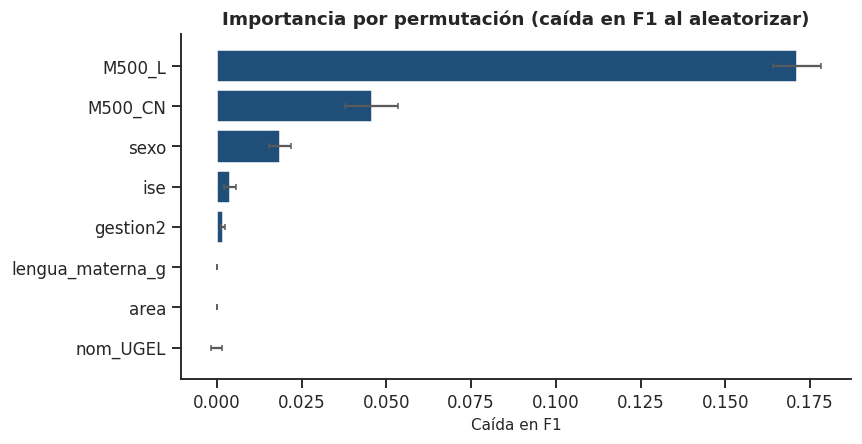

In [26]:
perm = permutation_importance(modelo_final, X_test, y_test,
                              n_repeats=10, random_state=RANDOM_STATE,
                              scoring='f1', n_jobs=-1)
imp = (pd.DataFrame({'variable': X_test.columns,
                     'importancia': perm.importances_mean,
                     'std': perm.importances_std})
         .sort_values('importancia', ascending=True))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(imp['variable'], imp['importancia'], xerr=imp['std'],
         color=PALETA['azul'], edgecolor='white', error_kw={'ecolor': PALETA['gris'], 'capsize': 2})
ax.set_title('Importancia por permutación (caída en F1 al aleatorizar)')
ax.set_xlabel('Caída en F1')
plt.tight_layout()
plt.show()

Los puntajes en otras áreas (Lectura y Ciencia y Tecnología) son los predictores más fuertes del riesgo en Matemática, lo cual es coherente con la hipótesis de habilidad general subyacente. El ISE aparece a continuación, confirmando que el contexto socioeconómico aporta información incluso después de controlar por el desempeño académico previo. Las categóricas administrativas tienen un aporte mucho menor: una vez que se conoce el desempeño y el ISE del estudiante, saber el tipo de gestión o la UGEL agrega poco.

## 13. Análisis del modelo en el perfil multidimensional de riesgo

Como validación externa del target, se evalúa qué tan bien el modelo entrenado para predecir riesgo en Matemática también identifica a los estudiantes en riesgo integral (≥2 áreas).

In [27]:
y_int_test = df.loc[X_test.index, 'riesgo_integral']
auc_integral = roc_auc_score(y_int_test, y_proba)
ap_integral = average_precision_score(y_int_test, y_proba)
print(f'ROC AUC contra riesgo integral: {auc_integral:.3f}')
print(f'PR  AUC contra riesgo integral: {ap_integral:.3f}')

ROC AUC contra riesgo integral: 0.965
PR  AUC contra riesgo integral: 0.952


Las probabilidades del modelo separan bien también a los estudiantes con dificultades en múltiples áreas. Esto sugiere que el modelo no está aprendiendo una particularidad de la prueba de Matemática, sino una señal de riesgo más general.

## 14. Caso de uso: ranking priorizado

Para el cliente del proyecto, la salida útil del modelo no es "sí/no" sino una **lista ordenada por urgencia de intervención**. Se generan los 15 estudiantes con mayor probabilidad de riesgo en el set de prueba, junto con sus rasgos observados.

In [28]:
ranking = X_test.copy()
ranking['prob_riesgo'] = y_proba
ranking['riesgo_real'] = y_test.values
ranking = ranking.sort_values('prob_riesgo', ascending=False).head(15)
ranking_vista = ranking[['gestion2', 'area', 'sexo', 'M500_L', 'M500_CN', 'ise',
                          'prob_riesgo', 'riesgo_real']]
ranking_vista['prob_riesgo'] = ranking_vista['prob_riesgo'].round(3)
ranking_vista['M500_L'] = ranking_vista['M500_L'].round(0)
ranking_vista['M500_CN'] = ranking_vista['M500_CN'].round(0)
ranking_vista['ise'] = ranking_vista['ise'].round(2)
ranking_vista

,gestion2,area,sexo,M500_L,M500_CN,ise,prob_riesgo,riesgo_real
110620,Estatal,Urbana,Mujer,481.0,326.0,0.07,0.994,1
112300,Estatal,Urbana,Mujer,463.0,279.0,0.40,0.994,1
120108,Estatal,Urbana,Mujer,479.0,309.0,NaN,0.993,1
121926,Estatal,Urbana,Mujer,479.0,282.0,NaN,0.993,1
110675,Estatal,Urbana,Mujer,484.0,354.0,0.15,0.993,1
117837,Estatal,Urbana,Mujer,510.0,301.0,0.36,0.992,1
116943,Estatal,Urbana,Mujer,473.0,312.0,-1.14,0.992,1
114246,Estatal,Urbana,Mujer,489.0,273.0,NaN,0.992,1
112893,Estatal,Urbana,Hombre,425.0,279.0,0.53,0.992,1
115996,Estatal,Urbana,Mujer,473.0,387.0,0.18,0.991,1


## 15. Discusión y limitaciones

**Hallazgos principales.** El modelo final logra un F1 de 0.80 y un ROC AUC de 0.87 sobre 2.550 estudiantes en el conjunto de prueba, con un recall de 0.80 al umbral por defecto. Al reajustar el umbral a 0.43, el recall sube a 0.85 manteniendo precision en 0.76: configuración recomendada para el caso de uso operativo, donde la prioridad declarada del cliente es no dejar pasar estudiantes en riesgo. Las variables más informativas son los puntajes en otras áreas evaluadas y el índice socioeconómico. Tanto el tipo de gestión como la UGEL pierden importancia una vez que se controla por estas dos dimensiones, lo que sugiere que el efecto agregado de "colegio privado" se explica en buena medida por la composición socioeconómica del alumnado.

Como validación externa, el mismo modelo entrenado solo con riesgo en Matemática alcanza ROC AUC de 0.97 al evaluarse contra el criterio multidimensional de riesgo (≥2 áreas). Esto respalda la idea de que las probabilidades del modelo capturan una señal de dificultad académica general, no un artefacto específico de la prueba de Matemática.

**Limitaciones del estudio.**

1. *Cobertura del fenómeno.* La Evaluación Muestral mide competencias en una escala estandarizada, no calificaciones bimestrales. El modelo predice riesgo según el criterio de la UMC, no necesariamente la nota de fin de bimestre que el cliente recoge en su sistema interno.
2. *Grado evaluado.* La EM 2022 cubre únicamente 2.º de secundaria. Trasladar el modelo a otros grados requiere reentrenamiento con la evaluación correspondiente al ciclo o, idealmente, con datos longitudinales del propio colegio cliente.
3. *Variables ausentes.* No se observan factores socioemocionales (autoeficacia, ansiedad, sentido de pertenencia) que la literatura señala como determinantes (Issah et al., 2023). En la implementación con el colegio cliente sería deseable incorporar instrumentos cortos para capturarlas.
4. *Sesgo de no-rendición.* Los estudiantes que no rindieron la prueba se excluyeron del modelado. Esa exclusión no es aleatoria: se concentra en zonas rurales y colegios estatales. El modelo describe a quienes sí rindieron y puede subrepresentar trayectorias de inasistencia crónica.
5. *Diseño muestral.* El entrenamiento no incorpora pesos muestrales. Las métricas reportadas reflejan el rendimiento sobre la muestra observada y son adecuadas para uso operativo, pero las cifras descriptivas representativas de la población deberían recalcularse con `peso_M`.

**Trabajo futuro.** El plan operativo del proyecto contempla validar el modelo con datos del colegio cliente bajo convenio, integrar variables socioemocionales en una segunda iteración y reentrenar al inicio de cada ciclo académico para mantener vigentes los patrones aprendidos.